# Обучение моделей (SBER / `models.sber`)

Загрузка parquet → сплит по времени → `StandardScaler` → оконный формат → **5 архитектур** (single). **6 эпох** обучения — для PyTorch-моделей; **LightGBM** — свои `n_estimators` (см. ячейку с циклом).

Запуск из каталога `src/models/sber` (или поправьте импорты / `PROJECT_ROOT`).

In [1]:
from pathlib import Path

_here = Path.cwd().resolve()
while True:
    if (_here / "src").is_dir():
        PROJECT_ROOT = _here
        break
    _here = _here.parent

DATA_DIR = PROJECT_ROOT / "src" / "data" / "dataset"

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from schema import FEATURE_COLS, INPUT_SIZE, TIME_COLUMN
from LSTM_model import LSTMModel
from GRU_model import GRUModel
from CNN_model import CNNModel
from Transformer_model import TransformerModel
#from LightGBM_model import LightGBMModel

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_SIZE:", INPUT_SIZE, "TIME:", TIME_COLUMN)

PROJECT_ROOT: /home/coftochka/Projects/CourseBDAMI3
INPUT_SIZE: 6 TIME: begin


/home/coftochka/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
SEQ_LEN = 30
EPOCHS = 6
FIT_KW = dict(epochs=EPOCHS, verbose=True, batch_size=256)

tickers = {
    "SBER": DATA_DIR / "SBER" / "SBER_BASIC_FULL.parquet",
}

VAL_FRAC = 0.70
TEST_FRAC = 0.85
PRIMARY_TICKER = next(iter(tickers))

In [3]:
def load_ohlcv_parquet(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if TIME_COLUMN not in df.columns:
        for c in ("timestamp", "time", "datetime"):
            if c in df.columns:
                df = df.rename(columns={c: TIME_COLUMN})
                break
    if TIME_COLUMN not in df.columns:
        raise ValueError(f"Нужна колонка времени. Колонки: {list(df.columns)}")
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN])
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Не хватает колонок {missing}")
    return df.sort_values(TIME_COLUMN).reset_index(drop=True)


raw = {}
for name, path in tickers.items():
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    data = load_ohlcv_parquet(path)
    data = data[data[TIME_COLUMN] >= pd.Timestamp("2024-01-01")]
    print(data.columns)
    data[list(FEATURE_COLS)].astype(np.float16)
    raw[name] = data
    
    print(f"{name}: {len(raw[name])} строк")

Index(['open', 'close', 'high', 'low', 'value', 'volume', 'begin'], dtype='str')
SBER: 552411 строк


/home/coftochka/.local/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)
/home/coftochka/.local/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)


In [4]:
def prepare_windows(df: pd.DataFrame, t_val, t_test, seq_len: int):
    df = df.copy().sort_values(TIME_COLUMN).reset_index(drop=True)
    df["target"] = np.log(df["close"].shift(-1) / df["close"])
    df = df.dropna(subset=["target"] + list(FEATURE_COLS))

    mask_tr = df[TIME_COLUMN] < t_val
    mask_vl = (df[TIME_COLUMN] >= t_val) & (df[TIME_COLUMN] < t_test)
    mask_te = df[TIME_COLUMN] >= t_test

    X_tr_raw = df.loc[mask_tr, list(FEATURE_COLS)].values.astype(np.float32)
    y_tr_raw = df.loc[mask_tr, "target"].values.astype(np.float32)
    X_vl_raw = df.loc[mask_vl, list(FEATURE_COLS)].values.astype(np.float32)
    y_vl_raw = df.loc[mask_vl, "target"].values.astype(np.float32)
    X_te_raw = df.loc[mask_te, list(FEATURE_COLS)].values.astype(np.float32)
    y_te_raw = df.loc[mask_te, "target"].values.astype(np.float32)

    scaler = StandardScaler()
    X_tr_raw = scaler.fit_transform(X_tr_raw)
    X_vl_raw = scaler.transform(X_vl_raw)
    X_te_raw = scaler.transform(X_te_raw)

    def make_windows(X, y):
        X_w, y_w = [], []
        for i in range(len(X) - seq_len + 1):
            X_w.append(X[i : i + seq_len])
            y_w.append(y[i + seq_len - 1])
        return np.array(X_w, dtype=np.float32), np.array(y_w, dtype=np.float32)

    return (
        *make_windows(X_tr_raw, y_tr_raw),
        *make_windows(X_vl_raw, y_vl_raw),
        *make_windows(X_te_raw, y_te_raw),
    )


t_min = max(df[TIME_COLUMN].min() for df in raw.values())
t_max = min(df[TIME_COLUMN].max() for df in raw.values())
total_seconds = (t_max - t_min).total_seconds()
t_val = t_min + pd.Timedelta(seconds=total_seconds * VAL_FRAC)
t_test = t_min + pd.Timedelta(seconds=total_seconds * TEST_FRAC)
print(f"train < {t_val} | val [{t_val}, {t_test}) | test >= {t_test}")

data = {name: prepare_windows(df, t_val, t_test, SEQ_LEN) for name, df in raw.items()}
X_train, y_train, X_val, y_val, X_test, y_test = data[PRIMARY_TICKER]

for name, pack in data.items():
    Xt, _, Xv, _, Xs, _ = pack
    print(f"{name}: train {Xt.shape}  val {Xv.shape}  test {Xs.shape}")

train < 2025-07-23 16:10:00 | val [2025-07-23 16:10:00, 2025-11-22 05:29:30) | test >= 2025-11-22 05:29:30
SBER: train (359754, 30, 6)  val (99767, 30, 6)  test (92802, 30, 6)



==================================================  LSTM  ==================================================
Epoch 3/6  train_loss=0.000000  val_loss=0.000000  lr=1.00e-03
Epoch 6/6  train_loss=0.000000  val_loss=0.000000  lr=1.00e-03


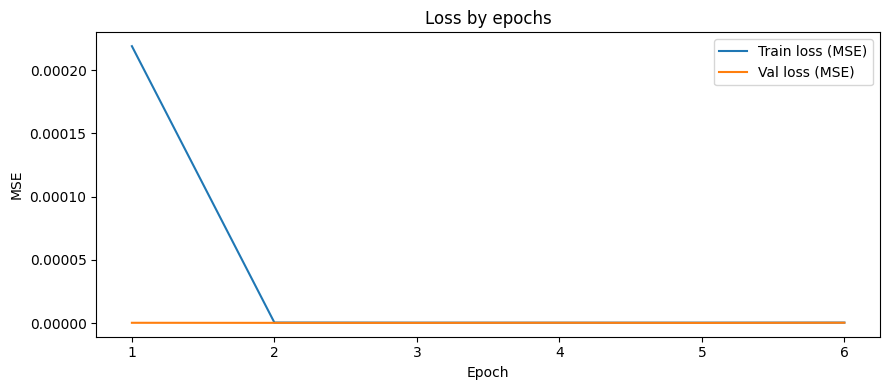

               mse      rmse       mae        r2  dir_accuracy        ic
LSTM  1.989668e-07  0.000446  0.000384 -1.792358      0.405562  0.009055

==================================================  GRU  ==================================================
Epoch 3/6  train_loss=0.000000  val_loss=0.000000  lr=1.00e-03
Epoch 6/6  train_loss=0.000000  val_loss=0.000000  lr=1.00e-03


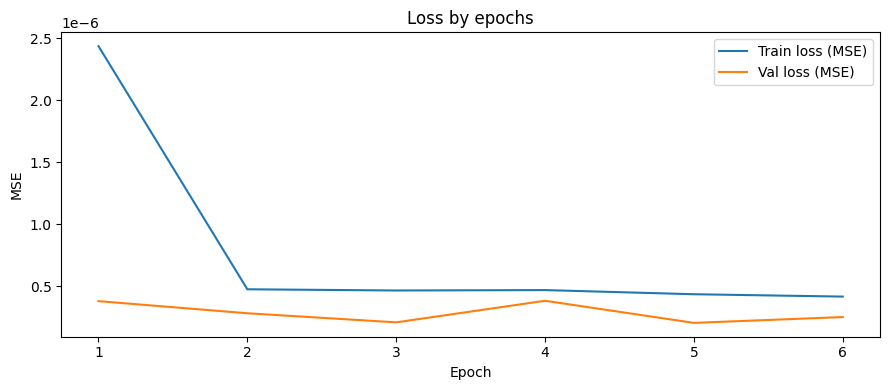

              mse      rmse       mae        r2  dir_accuracy       ic
GRU  1.143769e-07  0.000338  0.000256 -0.605199      0.411661 -0.00624

==================================================  CNN  ==================================================
Epoch 3/6  train_loss=0.000005  val_loss=0.000000  lr=1.00e-03
Epoch 6/6  train_loss=0.000000  val_loss=0.000000  lr=1.00e-03


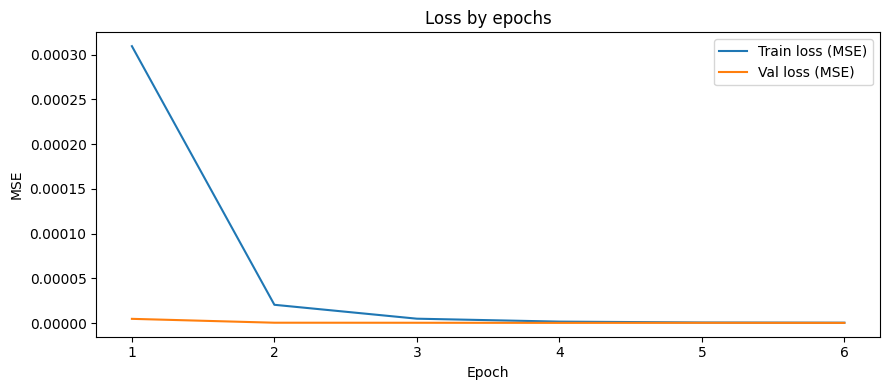

              mse      rmse       mae        r2  dir_accuracy        ic
CNN  7.634028e-08  0.000276  0.000168 -0.071382      0.412857  0.004355

==================================================  Transformer  ==================================================
Epoch 3/6  train_loss=0.000029  val_loss=0.000004  lr=1.00e-03
Epoch 6/6  train_loss=0.000002  val_loss=0.000000  lr=1.00e-03


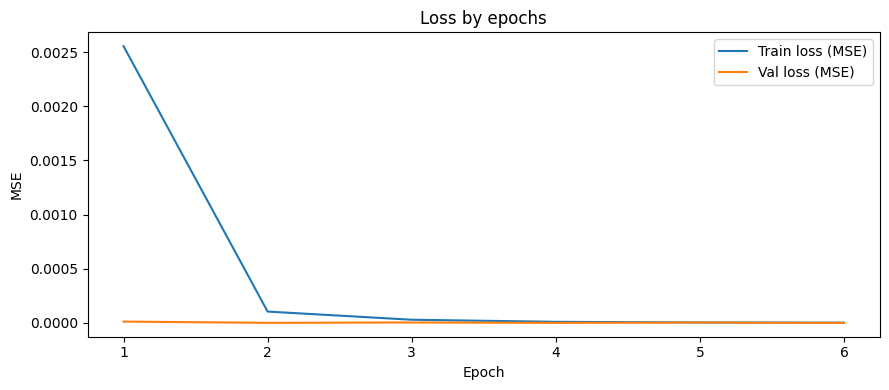

                      mse      rmse       mae        r2  dir_accuracy  \
Transformer  9.742082e-08  0.000312  0.000222 -0.367232      0.405239   

                   ic  
Transformer -0.009702  


In [5]:
models = [
    (LSTMModel(input_size=INPUT_SIZE, hidden_size=16, num_layers=2, seq_len=SEQ_LEN, mode="single"), "LSTM"),
    (GRUModel(input_size=INPUT_SIZE, hidden_size=16, num_layers=2, seq_len=SEQ_LEN, mode="single"), "GRU"),
    (CNNModel(input_size=INPUT_SIZE, num_filters=16, num_layers=2, seq_len=SEQ_LEN, mode="single"), "CNN"),
    (TransformerModel(input_size=INPUT_SIZE, d_model=16, nhead=4, seq_len=SEQ_LEN, mode="single"), "Transformer"),
 #   (LightGBMModel(input_size=INPUT_SIZE, seq_len=SEQ_LEN, mode="single", n_estimators=50), "LightGBM"),
]

trained = []
for model, name in models:
    print(f"\n{'=' * 50}  {name}  {'=' * 50}")
    if name == "LightGBM":
        # у LGBM fit(epochs=…) задаёт число деревьев, не «эпохи» как у torch
        model.fit(X_train, y_train, X_val=X_val, y_val=y_val, verbose=True)
    else:
        model.fit(X_train, y_train, X_val=X_val, y_val=y_val, **FIT_KW)
    model.plot_loss()
    print(model.scores(X_test, y_test, name, batch_size=256))
    trained.append((model, name))